## Analyzing a Single Completed Simulation
Dan Chen, Summer 2026

### Imports

In [ ]:
# === IMPORTS ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import pickle as pkl

from astropy import units as u
from pathlib import Path
from collections import defaultdict
from fractions import Fraction
from helpers import plot_prettier_lite
from accretion import *

import mmr_id
import rebound_sims as reb_sims

import warnings
warnings.filterwarnings('ignore')

plot_prettier_lite(save_dpi=500)

# === UNIT CONVERSIONS ===
AU = u.AU.to(u.cm)    
G = 4*np.pi**2 # in yr, AU, Msun
Msun = u.Msun.to(u.g) 
yr = u.yr.to(u.s)    
r_earth = u.earthRad.to(u.AU)
m_earth = u.Mearth.to(u.Msun)
r_sun = u.Rsun.to(u.AU) 

### Investigate a specific simulation run & plot its orbital evolution

Dataset 2, Sim 840
num_pl: 2, num_em: 20, num_ptsml: 0


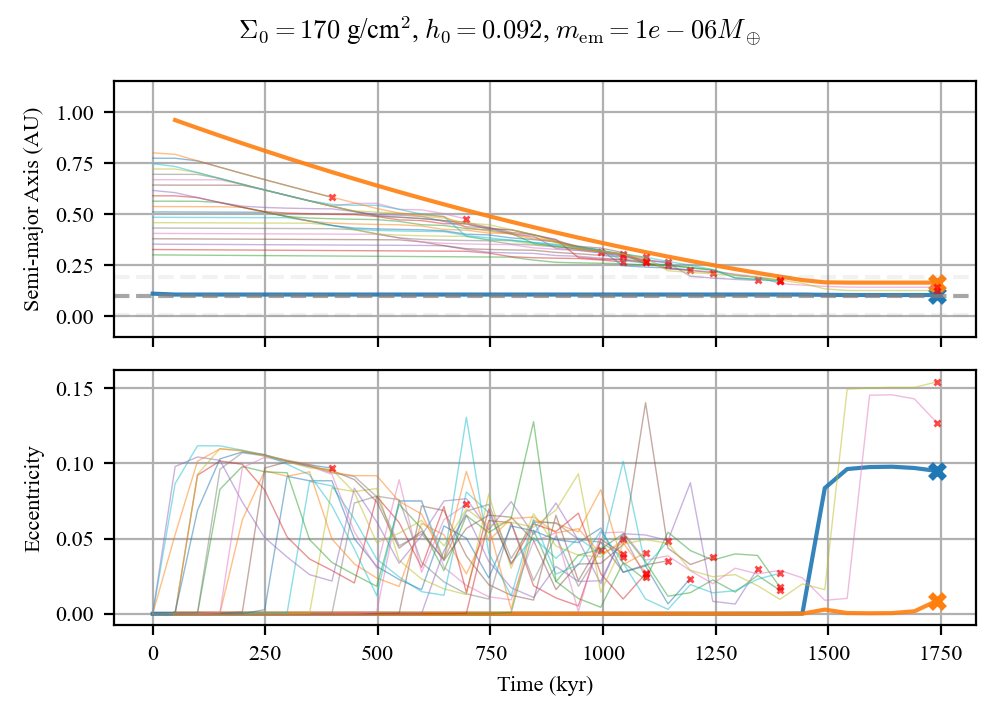

In [70]:
%matplotlib widget

def plot_system(saved_sim, elements, num_pl, num_em, num_ptsml, t_units='kyr'):
    '''
    Takes dataframes for planets and plots a, e, and P ratios over time.
    '''
    
    # Function to plot collision markers
    def plot_end_marker(ax, t, y, **kwargs):
        y = np.asarray(y)

        # Find valid entries
        valid = np.isfinite(y)

        # Only plot marker if the object disappears before the end
        if np.any(valid) and not valid[-1]:
            last_idx = np.where(valid)[0][-1]

            ax.plot(
                t[last_idx],
                y[last_idx],
                marker='x',
                linestyle='None',
                **kwargs
            )
    
    # could also try plotting log
    sim_data, metadata = saved_sim
    rock_names = list(sim_data.keys())
    
    rock_names = rock_names
    # num_em=1
    
    times = sim_data[rock_names[0]]['time']
    
    fig, axs = plt.subplots(len(elements), 1, sharex=True)
    fig.set_figwidth(5)
    fig.set_figheight(1.8*len(elements))

    time_factor = {'yr': 1, 'kyr': 1e3, 'Myr': 1e6}[t_units]
    pl_style = {'alpha': 0.9}
    em_style = {'alpha': 0.5, 'lw': 0.5} 
    ptsml_style = {'c': 'k', 'alpha': 0.9, 'lw': 0.2}

    if not isinstance(axs, (list, np.ndarray)): # if elements is one item
        axs = [axs]
    for i, ax in enumerate(axs):
        if elements[i] == 'a':
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot((times/time_factor)[:], sim_data[name]["a"][:], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["a"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["a"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["a"], color='r', ms=1, mew=0.5, alpha=0.6)
            
            # Plot ide location & width
            try:
                ax.axhline(metadata["ide_position"], color='gray', ls='--', alpha=0.7)
                ax.axhline(metadata["ide_position"] - metadata["ide_width"], color='gray', ls='--', alpha=0.1)
                ax.axhline(metadata["ide_position"] + metadata["ide_width"], color='gray', ls='--', alpha=0.1)
            except:
                pass
            
            ax.set_ylabel("Semi-major Axis (AU)")
            ax.set_ylim(-0.1,1.15)
            # ax.set_ylim(0.103,0.15) # inspect IDE
            
        elif elements[i] == "e":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["e"], **pl_style, label=name)
            
            # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["e"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["e"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["e"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Eccentricity")
        
        elif elements[i] == "P":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["P"], **pl_style, label=name)
            
            # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["P"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["P"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Period")
                 
        elif elements[i] == 'P_ratio':
            for i in range(num_pl):
                name = rock_names[i]
                if i < num_pl-1:
                    ax.plot(times/time_factor, sim_data[rock_names[i+1]]["P"]/sim_data[name]["P"], label=f"{name}+{rock_names[i+1]}")
                    
            for i in range(num_pl): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], c=f'C{i}', ms=5, mew=2.5)
            
            # Add horizontal lines for resonances
            first_res = [2/1, 3/2, 4/3, 5/4]
            second_res = [3/1, 5/3, 7/5]
            third_res = [4/1, 5/2, 7/4, 8/5]
    
            for r in first_res:
                ax.axhline(r, color='gray', ls='--', alpha=0.7)
            for r in second_res:
                ax.axhline(r, color='blue', ls='--', alpha=0.5)
            # for r in third_res:
            #     ax3.axhline(r, color='red', ls='--', alpha=0.5)
            
            ax.set_ylabel("Period ratio")
            ax.set_ylim(0.9,3.1)
            
        elif elements[i] == 'P_ratio_em_b':     
            for i in range(num_pl, num_pl+num_em): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["P"]/sim_data['planet b']["P"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], color='r', ms=1, mew=0.5, alpha=0.6)
            
            # Add horizontal lines for resonances
            first_res = [3/2, 4/3, 5/4, 6/5, 7/6, 8/7, 9/8, 10/9]
            second_res = [5/3, 7/5]
            third_res = [4/1, 5/2, 7/4, 8/5]
    
            for i, r in enumerate(first_res):
                ax.axhline(r, color='gray', ls='--', alpha=0.7)
            # for r in second_res:
            #     ax.axhline(r, color='blue', ls='--', alpha=0.5)
            # for r in third_res:
            #     ax3.axhline(r, color='red', ls='--', alpha=0.5)
            
            ax.set_ylabel("Period ratio with planet b")
            ax.set_ylim(1.08,1.53)
            ax.set_yscale('log')
            ax.set_yticks(first_res)
            ax.set_yticklabels(['3:2', '4:3', '5:4', '6:5', '7:6', '8:7', '9:8', '10:9'], fontsize=5)
            ax.minorticks_off()
            
        elif elements[i] == 'P_ratio_em_c':     
            for i in range(num_pl, num_pl+num_em): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data['planet c']["P"]/sim_data[name]["P"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["P"], color='r', ms=1, mew=0.5, alpha=0.6)
            
            # Add horizontal lines for resonances
            first_res = [3/2, 4/3, 5/4, 6/5, 7/6, 8/7, 9/8, 10/9]
            second_res = [5/3, 7/5]
            third_res = [4/1, 5/2, 7/4, 8/5]
    
            for i, r in enumerate(first_res):
                ax.axhline(r, color='gray', ls='--', alpha=0.7)
            # for r in second_res:
            #     ax.axhline(r, color='blue', ls='--', alpha=0.5)
            # for r in third_res:
            #     ax3.axhline(r, color='red', ls='--', alpha=0.5)
            
            ax.set_ylabel("Period ratio with planet c")
            ax.set_ylim(1.08,1.53)
            ax.set_yscale('log')
            ax.set_yticks(first_res)
            ax.set_yticklabels(['3:2', '4:3', '5:4', '6:5', '7:6', '8:7', '9:8', '10:9'], fontsize=5)
            ax.minorticks_off()

        elif elements[i] == "inc":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["inc"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["inc"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["inc"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["inc"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel("Inclination")
        
        elif elements[i] == "pomega":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(0, num_em, 1):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **em_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em, 1): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, sim_data[name]["pomega"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, sim_data[name]["pomega"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel(r"$\varpi$")
            
        elif elements[i] == "log_tau_a_Omega":
            for i in range(num_pl, num_pl+num_em): # embryos
                name = rock_names[i]
                tau_a = (-sim_data['planet c']["tau_a"]**-1 - (-sim_data[name]["tau_a"]**-1))**-1 
                Omega = 2*np.pi/sim_data[name]["P"]
                ax.plot(times/time_factor, np.log10(tau_a*Omega), **em_style, label=name)
            ax.set_ylabel(r"$\log \tau_a \Omega$")
            # ax.set_ylim(-5000000, 25000)
            
        elif elements[i] == "log_K2":
            for i in range(num_pl, num_pl+num_em): # embryos
                name = rock_names[i]
                tau_a = ((-sim_data['planet c']["tau_a"])**-1 - (-sim_data[name]["tau_a"])**-1)**-1
                ax.plot(times/time_factor, np.log10(tau_a / -sim_data['planet c']["tau_e"]), **em_style, label=name)
            ax.set_ylabel(r"$\log K_2$")
        
        elif elements[i] == "tau_a":
            for i in range(num_pl):
                name = rock_names[i]
                if name == 'planet b':
                    continue # (use this to not show at IDE)
                ax.plot(times/time_factor, -sim_data[name]["tau_a"], **pl_style, c=f'C{i}', label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                if name == 'planet b':
                    continue # (use this to not show at IDE)
                plot_end_marker(ax, times/time_factor, -sim_data[name]["tau_a"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(num_em):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, -sim_data[name]["tau_a"], **em_style)
                plot_end_marker(ax, times/time_factor, -sim_data[name]["tau_a"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, -sim_data[name]["tau_a"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, -sim_data[name][" tau_a"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel(r"$\tau_a$")
        
        elif elements[i] == "tau_e":
            for i in range(num_pl):
                name = rock_names[i]
                ax.plot(times/time_factor, -sim_data[name]["tau_e"], **pl_style, label=name)
            
         # Another loop to prevent color confusion
            for i in range(num_pl):
                name = rock_names[i]
                plot_end_marker(ax, times/time_factor, -sim_data[name]["tau_e"], c=f'C{i}', ms=5, mew=2.5)

            for i in range(num_em):
                name = rock_names[i+num_pl]
                ax.plot(times/time_factor, -sim_data[name]["tau_e"], **em_style)
                plot_end_marker(ax, times/time_factor, -sim_data[name]["tau_e"], color='r', ms=2, mew=1, alpha=0.7)
            
            for i in range(0, len(rock_names)-num_pl-num_em): # don't use num_ptsml as it doesn't include replenished ptsmls
                name = rock_names[i+num_pl+num_em]
                ax.plot(times/time_factor, -sim_data[name]["tau_e"], **ptsml_style)
                plot_end_marker(ax, times/time_factor, -sim_data[name][" tau_e"], color='r', ms=1, mew=0.5, alpha=0.6)
                    
            ax.set_ylabel(r"$\tau_e$")
            
        
    axs[-1].set_xlabel("Time (kyr)")
    for ax in axs:
        # ax.legend(fontsize=6)
        ax.grid(True)

    fig.subplots_adjust(hspace=0)

    if 'm_em' in metadata:
        plt.suptitle(f"$\Sigma_0={metadata['Sigma_1au']:.0f}$ g/cm$^2$, $h_0={metadata['h_1au']:.3f}$, $m_{{\\rm em}}={metadata['m_em']:.3g} M_\\oplus$")
    else:
        plt.suptitle(f"$\Sigma_0={metadata['Sigma_1au']:.0f}$ g/cm$^2$, $h_0={metadata['h_1au']:.3f}$")
    plt.tight_layout(); plt.show()
    # plt.savefig("Figures/orbital_evo.svg", bbox_inches="tight")

dataset_id = 2
sim_id = 840

elements = ['a', 
            'e', 
            # 'P_ratio_em_b',
            # 'P_ratio_em_c',
        ]

for sim_id in range(sim_id, sim_id+1, 1):
# for sim_id in inside_d:
    base_dir = Path.cwd()
    file_path = base_dir.parent / f"sim_results/dataset{dataset_id}" / f"sim{sim_id}.h5"

    try:
        saved_sim = reb_sims.load_simulation_run(file_path)
    except FileNotFoundError:
        print(f"Sim {sim_id} not found")
        continue

    sim_data, metadata = saved_sim
    m_star = metadata['m_star'] 
    rock_names = list(sim_data.keys())
    rocks = {p: sim_data[p] for p in rock_names}
    num_pl, num_em, num_ptsml = metadata['num_pl'], metadata['num_em'], metadata['num_ptsml']

    print(f"Dataset {dataset_id}, Sim {sim_id}")    
    print(f"num_pl: {metadata['num_pl']}, num_em: {metadata['num_em']}, num_ptsml: {metadata['num_ptsml']}") 
    
    plot_system(saved_sim, elements, num_pl, num_em, num_ptsml)

### Plot libration of the resonance angle $\phi$

=== Embryo 1 ===
True period ratio: 1.9989
p, q: 2, 1
Libration amplitude: 16.2 deg


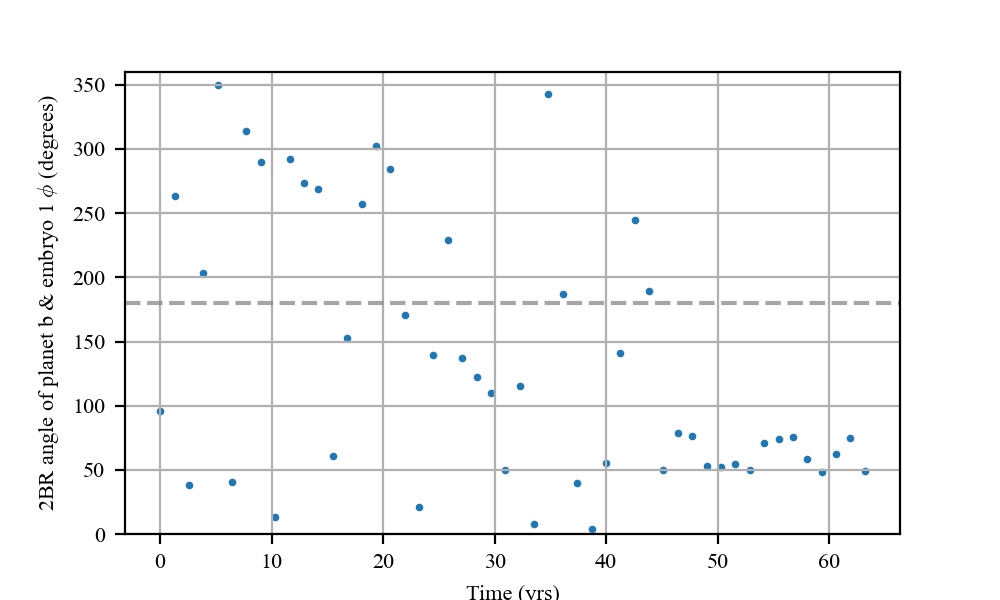

True period ratio: 1.2009
p, q: 6, 5
Libration amplitude: 48.1 deg


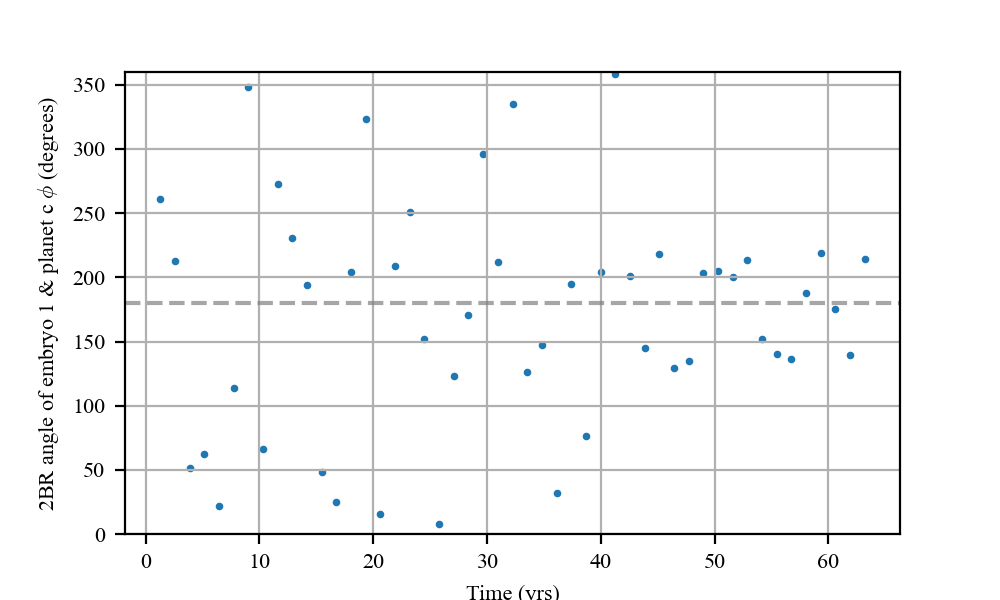

In [67]:
# mmr_id.plot_libration(m_star, rocks['planet b'], rocks['planet c'], N=100, forced_pq=None)
# mmr_id.plot_libration(m_star, rocks['planet b'], rocks['embryo 0'], N=25, forced_pq=None)
for i in range(20):
    if rocks[f'embryo {i}']['a'].iloc[-1] < rocks['planet c']['a'].iloc[-1]:
        print(f"=== Embryo {i} ===")
        mmr_id.plot_libration(m_star, rocks['planet b'], rocks[f'embryo {i}'], N=15, pomega='mixed', forced_pq=None)
        mmr_id.plot_libration(m_star, rocks[f'embryo {i}'], rocks['planet c'], N=15, pomega='mixed', forced_pq=None)

In [ ]:
# 3BR
mmr_id.plot_libration(m_star, rocks['planet b'], rocks[f'embryo 4'], rocks['planet c'], N=100, pomega='mixed')

In [68]:
collision_df = get_collision_log(metadata, )
fates_df = get_particle_fates(metadata, )
summary = summarize_accretion(metadata, collision_df, fates_df)
summary

,n_ems,n_ptsmls,embryo %,ptsml %
particle,,,,
embryo 1,17,0,85.0,0
planet c,1,0,5.0,0
Survived,2,0,10.0,0


### Plot $a$ vs. $e$ at given snapshots

In [ ]:
def plot_ae_snapshot(saved_sim, *snapshot_times):
    """Plot a vs e at a one or more snapshots.
    """

    sim_data = saved_sim[0]

    # Use first body to get time array
    first_name = rock_names[0]
    times = sim_data[first_name]["time"]

    # Get idxs that best match the times given
    snapshot_idxs = np.array([
        np.argmin(np.abs(times - t))
        for t in snapshot_times
    ]) 

    num_plots = len(snapshot_times)
    fig, axs = plt.subplots(num_plots, 1, sharex=True, figsize=(4.5, 1.2 * num_plots))

    for i, ax in enumerate(axs):
        snapshot_idx = snapshot_idxs[i]
        
        # planets
        for j in range(num_pl):
            name = rock_names[j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=100,
                # label=name,
                zorder=3,
                alpha=1
            )

        # embryos
        for j in range(num_em):
            name = rock_names[num_pl + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=25,
                color='navy',
                alpha=0.75
            )

        # planetesimals
        for j in range(num_ptsml):
            name = rock_names[num_pl + num_em + j]

            ax.scatter(
                sim_data[name]["a"][snapshot_idx],
                sim_data[name]["e"][snapshot_idx],
                s=5,
                c='k',
                alpha=0.75
            )

        if i == num_plots - 1:
            ax.set_xlabel("Semi-major axis (AU)")
        ax.set_ylim(-0.01, 0.31)
        ax.set_xlim(0.07, 2.5)
        ax.set_xscale('log')
        ax.grid(True)
        ax.set_axisbelow(True)

        t = times[snapshot_idx]
        ax.legend(title=f"t = {t/1000:.1f} kyr", title_fontsize=8, labelspacing=0)
        
    fig.supylabel('Eccentricity')
    fig.subplots_adjust(hspace=0)
    # plt.suptitle("Snapshots of Disk Evolution")
    plt.tight_layout()
    plt.show()
    # plt.savefig("disk_snapshots.svg", bbox_inches="tight")
    
end = saved_sim[0]['planet b']['time'].iloc[-1]
# plot_ae_snapshot(saved_sim, 0, 6e3, end/5+50, 2*end/5+50, 3*end/5+50, 4*end/5+50)

### Plot cumulative mass distribution of planetesimals and embryos

In [ ]:
planet_outcomes = pd.read_hdf("dfs/planet_outcomes7.h5", key="df") # Load data

def plot_cumulative_mass_distribution(end_idx, *sim_ids):
    """
    Plot the initial cumulative planetesimal mass distribution and the
    snapshot distributions for each simulation.

    Planet b/c/d locations at the snapshot are shown using the same color as
    that simulation's planetesimal CDF.
    """

    def get_ptsml_distribution(sim_data, metadata, snapshot_idx):
        a = []
        m = []

        # Include all planetesimals, including replenished ones
        ptsml_names = [
            name for name in sim_data.keys()
            if name.startswith("ptsml")
        ]

        for name in ptsml_names:
            df = sim_data[name]

            if snapshot_idx >= len(df):
                continue

            aval = df["a"].iloc[snapshot_idx]
            if np.isnan(aval):
                continue

            a.append(aval)
            m.append(metadata["m_ptsml"])

        a = np.asarray(a)
        m = np.asarray(m)

        order = np.argsort(a)

        return a[order], np.cumsum(m[order])

    def get_planet_locations(sim_data, metadata, snapshot_idx):
        locations = {}

        for i in range(metadata["num_pl"]):
            name = f"planet {chr(ord('b') + i)}"

            if name not in sim_data:
                continue

            df = sim_data[name]

            if snapshot_idx >= len(df):
                continue

            aval = df["a"].iloc[snapshot_idx]
            if np.isnan(aval):
                continue

            locations[name] = aval

        return locations

    fig, ax = plt.subplots(figsize=(6, 4))

    base_dir = Path.cwd()
    file_paths = [
        base_dir.parent / f"sim_results/dataset7" / f"sim{sim_id}.h5"
        for sim_id in sim_ids
    ]
    saved_sims = [
        reb_sims.load_simulation_run(file_path)
        for file_path in file_paths
    ]

    # Plot initial planetesimal distribution once
    sim_data, metadata = saved_sims[0]
    a0, M0 = get_ptsml_distribution(sim_data, metadata, 0)

    ax.step(
        a0,
        M0,
        where="post",
        lw=2,
        color="k",
        label="Initial"
    )

    # Plot each snapshot state and planet locations
    for i, (sim_data, metadata) in enumerate(saved_sims):
        af, Mf = get_ptsml_distribution(sim_data, metadata, end_idx)

        label = rf"$\tau_a$={int(planet_outcomes.iloc[sim_ids[i]]['tau_a (kyr)'])} kyr"

        line = ax.step(
            af,
            Mf,
            where="post",
            lw=2,
            alpha=0.8,
            label=label
        )[0]

        color = line.get_color()

        planet_locations = get_planet_locations(sim_data, metadata, end_idx)

        for planet_name, aval in planet_locations.items():
            ax.axvline(
                aval,
                color=color,
                ls="--",
                lw=1.2,
                alpha=0.75
            )

            ax.text(
                aval,
                ax.get_ylim()[1] * 0.96,
                planet_name[-1],
                color=color,
                ha="center",
                va="top",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_xlim(0.1)
    ax.set_xscale("log")
    ax.set_xlabel("Semi-major axis (AU)")
    ax.set_ylabel("Cumulative mass of planetesimals ($M_\\oplus$)")
    ax.grid(True)
    ax.legend()
    plt.tight_layout()

end_idx = 99
sim_ids = [198, 76, 54]
# plot_cumulative_mass_distribution(end_idx, *sim_ids)

### Plotting number of planetesimals captured in resonance

In [ ]:
def plot_ptsmls_res(saved_sim, num_pl, num_em, t_units='kyr', tol=0.01, k=2):
    """
    Plot the number of planetesimals interior to planet b that are within tol
    of the k:k-1 resonance with planet b.

    For an interior planetesimal:
        P_out = P_b
        P_in = P_ptsml

    Delta = ((k-1)/k) * (P_b / P_ptsml) - 1
    """

    sim_data, metadata = saved_sim
    rock_names = list(sim_data.keys())

    time_factor = {'yr': 1, 'kyr': 1e3, 'Myr': 1e6}[t_units]

    b_name = 'planet b'
    if b_name not in sim_data:
        b_name = rock_names[0]

    times = sim_data[b_name]['time']
    P_b = sim_data[b_name]['P']

    # Include replenished planetesimals too
    ptsml_names = rock_names[num_pl:] # or num_pl+num_em for ptsmls only

    counts = np.zeros(len(times), dtype=int)

    for name in ptsml_names:
        P_ptsml = sim_data[name]['P']
        valid = np.isfinite(P_ptsml) & np.isfinite(P_b)
        Delta = ((k-1)/k) * (P_b / P_ptsml) - 1
        in_res = valid & (np.abs(Delta) <= tol)
        counts += in_res.astype(int)

    fig, ax = plt.subplots(figsize=(5, 2.5))

    ax.plot(times / time_factor, counts, color='k', lw=1.5)

    ax.set_xlabel(f"Time ({t_units})")
    ax.set_ylabel(f"Planetesimals in {k}:{k-1} MMR with b")
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    return counts

# counts = plot_ptsmls_res(saved_sim, num_pl=metadata['num_pl'], num_em=metadata['num_em'], t_units='kyr', tol=0.03, k=2)